In [3]:
import pandas as pd
import matplotlib.pyplot as plt
#import glob

dir_name = "(Directory path)"

# Concate dataframe
all_data = []
for year in range(2013, 2024):
    file = f"Hisaki_geometry_radiation{year}.csv" #f => input year to {year}
    df = pd.read_csv(dir_name + file, parse_dates=['Time'])
    df['Year'] = year
    all_data.append(df)

df_all = pd.concat(all_data, ignore_index=True)

# Lon. filter
df_all['Time'] = pd.to_datetime(df_all['Time'])
df_all['Year'] = df_all['Time'].dt.year

df_filtered = df_all[(df_all['Lon'] >= 60) & (df_all['Lon'] <= 150) ].copy() #60-150 deg. (Yoshioka et al., 2021)
df_filtered = df_filtered.set_index('Time')
df_smoothed = df_filtered
df_smoothed = df_filtered.groupby('Year').apply(
    lambda g: g.rolling('5min').mean()
).reset_index(level=0, drop=True).reset_index()


In [28]:
df_smoothed.head()

,Time,DOY,Year,Lon,Lat,LT,Geocenter,Count
0,2013-11-19 01:48:42,323.075486,2013.0,123.388800,23.04890,10.277800,7528.0,4.00
1,2013-11-19 01:49:42,323.075834,2013.0,124.970800,23.57480,10.391600,7528.0,6.00
2,2013-11-19 01:50:42,323.076181,2013.0,126.570933,24.07500,10.506633,7528.0,8.00
3,2013-11-19 01:51:42,323.076528,2013.0,128.188950,24.54825,10.622825,7528.0,8.75
4,2013-11-19 01:52:42,323.076875,2013.0,129.824480,24.99336,10.740200,7527.8,9.60


36     2013-11-20 04:35:23
719    2013-12-03 11:49:45
896    2013-12-04 10:49:12
1061   2013-12-06 10:25:58
1074   2013-12-06 12:09:58
1199   2013-12-10 11:54:00
1536   2013-12-22 12:26:42
1556   2013-12-22 14:12:42
2038   2013-12-26 13:53:00
Name: Time, dtype: datetime64[ns] 36      324.190891
719     337.491493
896     338.449444
1061    340.433310
1074    340.506227
1199    344.494444
1536    356.517847
1556    356.591805
2038    360.577083
Name: DOY, dtype: float64
Series([], Name: Time, dtype: datetime64[ns]) Series([], Name: DOY, dtype: float64)
62395    2015-01-13 19:15:22
75752    2015-03-18 18:01:30
94762    2015-06-23 07:01:00
105243   2015-08-28 20:24:27
111771   2015-10-07 06:29:20
112551   2015-10-11 04:09:27
Name: Time, dtype: datetime64[ns] 62395      13.802338
75752      77.751042
94762     174.290972
105243    240.850313
111771    280.270370
112551    284.173229
Name: DOY, dtype: float64
134287   2016-02-22 22:00:33
Name: Time, dtype: datetime64[ns] 134287    53.917049

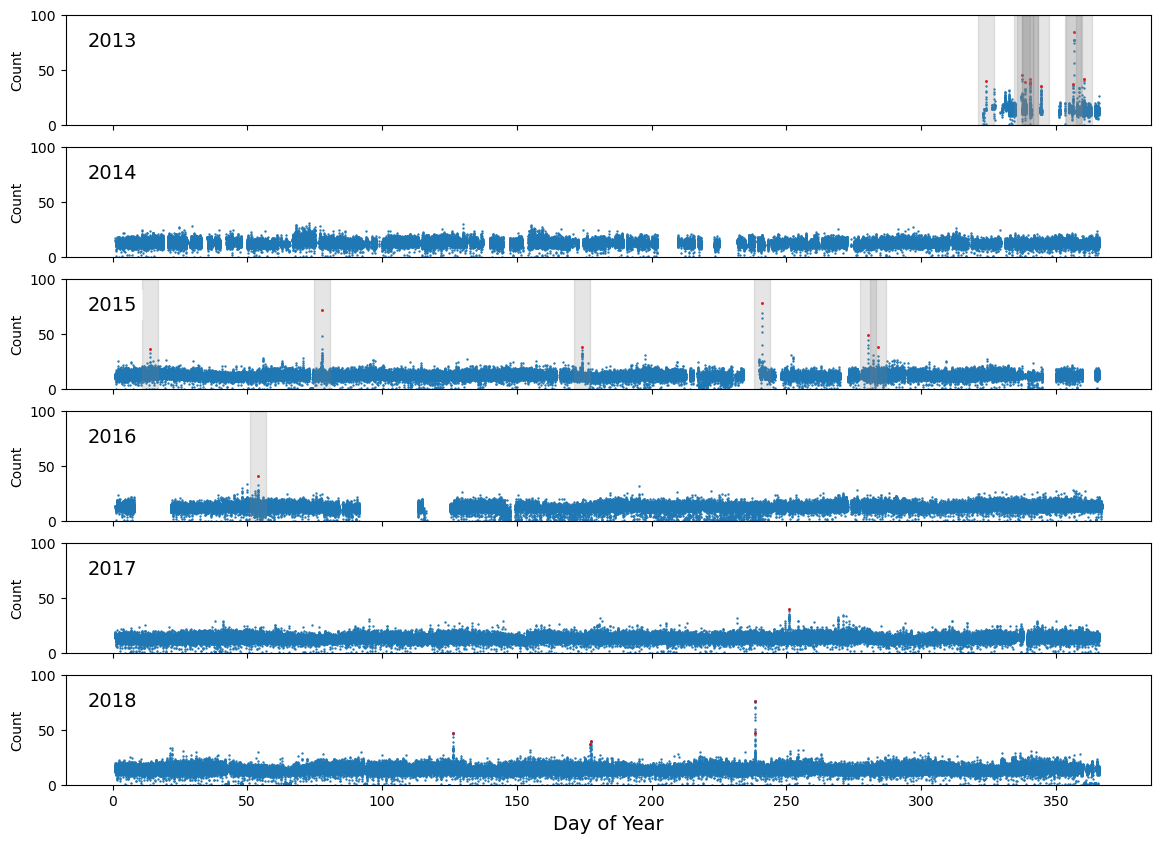

In [5]:
### from scipy.signal import find_peaks
from scipy.signal import find_peaks

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(14, 10), sharex=True)
all_peaks_idx = []

for i, year in enumerate(range(2013, 2019)):
    ax = axes[i]
    df_year = df_smoothed[df_smoothed['Year'] == year]
    ax.scatter(df_year['DOY'], df_year['Count'], s=0.5)  # smoothed Count
    ax.set_ylabel("Count", fontsize=10)
    #ax.set_xlim(50, 68)
    ax.set_ylim(0, 100)
    ax.tick_params(labelsize=10)
    ax.text(0.02, 0.85, f"{year}", transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    # Peak prominence
    peaks, properties = find_peaks(df_year['Count'], prominence=10, height=35)
    orig_idx = df_year.index.to_numpy()[peaks]
    all_peaks_idx.extend(orig_idx) 
    
    #Visualize
    ax.scatter(df_year['DOY'].iloc[peaks], df_year['Count'].iloc[peaks], s=1,color="red") 
    if year < 2017:    
        for j in peaks:
            ax.axvspan(df_year['DOY'].iloc[j]-3,df_year['DOY'].iloc[j]+3,alpha=0.2,color="grey")
    print(df_year['Time'].iloc[peaks],df_year['DOY'].iloc[peaks])


plt.xlabel("Day of Year", fontsize=14)
plt.subplots_adjust(hspace=0.2)
plt.savefig("Time variations 2013-2018.png",dpi=600)
plt.show()



342784   2019-02-26 10:12:02
Name: Time, dtype: datetime64[ns]
Series([], Name: Time, dtype: datetime64[ns])
492002   2021-08-06 08:57:00
506828   2021-11-08 21:23:59
510598   2021-12-08 08:31:25
513341   2021-12-24 02:55:00
Name: Time, dtype: datetime64[ns]
515781   2022-01-09 16:27:00
520637   2022-02-16 02:38:02
521091   2022-02-18 21:52:06
522268   2022-02-24 22:46:30
527377   2022-03-23 13:05:26
527913   2022-03-26 13:40:52
531743   2022-04-17 03:35:45
533440   2022-04-26 22:40:17
552137   2022-08-10 03:10:51
564919   2022-10-19 22:07:15
566440   2022-10-29 19:04:34
568431   2022-11-12 13:40:40
Name: Time, dtype: datetime64[ns]
579977   2023-01-28 07:54:42
585585   2023-03-06 16:11:18
599389   2023-05-30 03:47:00
599642   2023-05-31 04:36:55
601355   2023-06-08 03:41:00
602225   2023-06-13 00:16:19
602870   2023-06-15 22:58:00
624433   2023-10-07 02:28:00
626457   2023-10-18 21:17:17
628129   2023-10-28 16:23:34
632908   2023-11-20 11:08:11
Name: Time, dtype: datetime64[ns]


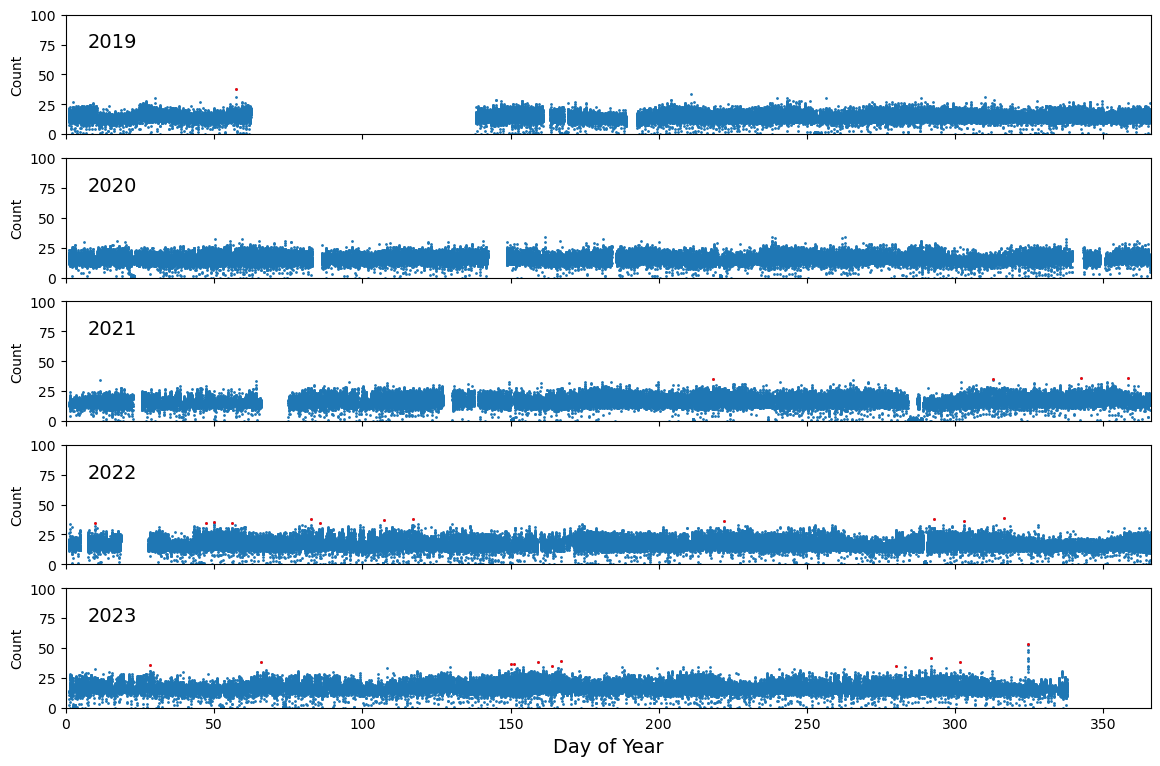

In [8]:
from scipy.signal import find_peaks
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 9), sharex=True) 

for i, year in enumerate(range(2019, 2024)):
    ax = axes[i]
    df_year = df_smoothed[df_smoothed['Year'] == year]
    ax.scatter(df_year['DOY'], df_year['Count'], s=1)  
    #ax.set_title(f"Year {year}", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_xlim(0, 366)
    ax.set_ylim(0, 100)
    ax.tick_params(labelsize=10)
    
    ax.text(0.02, 0.85, f"{year}", transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    peaks, properties = find_peaks(df_year['Count'], prominence=10, height=35)
    ax.scatter(df_year['DOY'].iloc[peaks], df_year['Count'].iloc[peaks], s=1,color="red") 
    print(df_year['Time'].iloc[peaks])


plt.xlabel("Day of Year", fontsize=14)
plt.savefig("Time variations 2019-2023.jpg",dpi=600)
plt.subplots_adjust(hspace=0.2)  
plt.show()
